In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn import tree
from sklearn import model_selection
from sklearn import linear_model #линейные модели
from sklearn import metrics
from sklearn import ensemble

In [132]:
dt = pd.read_csv('weatherAUS.csv')
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [133]:
#Сколько суммарно пропусков в данных?
dt.isnull().sum().sum()

np.int64(343248)

In [134]:
#dt.isnull().sum()
percent_missing = dt.isnull().sum() * 100 / len(dt)
percent_missing

Date              0.000000
Location          0.000000
MinTemp           1.020899
MaxTemp           0.866905
Rainfall          2.241853
Evaporation      43.166506
Sunshine         48.009762
WindGustDir       7.098859
WindGustSpeed     7.055548
WindDir9am        7.263853
WindDir3pm        2.906641
WindSpeed9am      1.214767
WindSpeed3pm      2.105046
Humidity9am       1.824557
Humidity3pm       3.098446
Pressure9am      10.356799
Pressure3pm      10.331363
Cloud9am         38.421559
Cloud3pm         40.807095
Temp9am           1.214767
Temp3pm           2.481094
RainToday         2.241853
RainTomorrow      2.245978
dtype: float64

In [135]:
#В некоторых признаках пропусков более 40 % — удалите такие признаки. Сколько их было?
Counter = 0
for n in range(len(percent_missing)):
    if percent_missing.values[n] > 40:
        dt = dt.drop(percent_missing.keys()[n], axis=1)
        Counter = Counter + 1

Counter

3

In [136]:
def YesNo(X):
    if X == 'Yes':
        return 1
    elif X == 'No':
        return 0

In [137]:
dt['RainToday'] = dt['RainToday'].apply(YesNo)
dt['RainTomorrow'] = dt['RainTomorrow'].apply(YesNo)

In [138]:
#Вычислите среднее арифметическое для преобразованного признака RainToday и запишите его в ответ, предварительно округлив до двух знаков после точки-разделителя
round(dt['RainToday'].mean(),2)

np.float64(0.22)

In [139]:
dt['Date'] = pd.to_datetime(dt['Date'])
dt['Month'] = dt['Date'].dt.month
dt = dt.drop('Date', axis=1)
dt['Month'].value_counts()

Month
3     13361
5     13353
1     13236
6     12684
10    12028
8     12028
7     12025
11    11669
9     11640
4     11550
12    11093
2     10793
Name: count, dtype: int64

In [140]:
#Определите, какой месяц имеет самую большую часть дождливых дней относительно всех дней месяца.
dt.groupby('Month').agg({'RainToday': lambda rain: 100*rain.sum()/rain.count()}).sort_values(by='RainToday', ascending=False).unstack().keys()[0]


('RainToday', np.int32(7))

In [141]:
#Сколько теперь признаков в данных, если считать целевую переменную?
categoricals = ['Month', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
dt_coded = pd.get_dummies(dt, columns=categoricals)
dt_coded.shape[1]

124

In [142]:
dt_coded = dt_coded.dropna()

In [143]:
X = dt_coded.drop(['RainTomorrow'], axis=1)
y = dt_coded['RainTomorrow']

In [144]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=31)#stratify=y, 
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (54779, 123)
Test shape: (23478, 123)


In [145]:
#Каково среднее значение целевой переменной на тестовой выборке?
round(sum(y_test)/len(y_test), 2)

0.23

In [146]:
#Сделайте оценку стандартного отклонения для среднего значения минимальной температуры для обучающей выборки (то есть для среднего значения по признаку MinTemp). Для этого сгенерируйте 1000 случайных выборок из наших данных — каждая из них должна быть такого же объёма, как и обучающая выборка. Для генерации выборки используйте np.random.randint(): сгенерируйте необходимое количество индексов и по ним извлеките соответствующие элементы выборки. Случайность фиксируйте с помощью np.random.seed(31)
target = X_train['MinTemp'].values
std_div = []

for n in range(1000):
    #np.random.seed(31)
    net = np.random.randint(target.shape[0], size=len(target))
    bootstrap_sample = target[net]
    std_div.append(np.mean(bootstrap_sample))
round(np.std(std_div), 2)
    

np.float64(0.03)

In [147]:
#Создаём объект класса LogisticRegression
log_reg = linear_model.LogisticRegression()
#Обучаем модель, минизируя logloss
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
#Выводим результирующие коэффициенты
print('Roc_acu score: {:.2f}'.format(metrics.roc_auc_score(y_test, y_pred_log)))

Roc_acu score: 0.73


c:\Users\LNV\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [148]:
params = {'max_leaf_nodes': list(range(2, 10)), 'min_samples_split': [2, 3, 4], 'max_depth': [5,7,9,11]}

In [149]:
grid_search = model_selection.GridSearchCV(
    estimator = tree.DecisionTreeRegressor(random_state=42), 
    param_grid=params, 
    cv=3,
    n_jobs = -1,
    #scoring='accuracy'
)  

In [150]:
grid_search.fit(X_train, y_train) 
y_pred_tree_1 = grid_search.predict(X_test)
print('Best parameters: ', grid_search.best_params_)
print('Roc_acu score: ', round(metrics.roc_auc_score(y_test, y_pred_tree_1), 2))

Best parameters:  {'max_depth': 5, 'max_leaf_nodes': 9, 'min_samples_split': 2}
Roc_acu score:  0.82


In [151]:
forest1 = ensemble.RandomForestRegressor(n_estimators=100, random_state = 31, n_jobs = -1)
forest1.fit(X_train, y_train)
y_pred_forest1 = forest1.predict(X_test)
#Выводим результирующие коэффициенты
print('Roc_acu score: ', round(metrics.roc_auc_score(y_test, y_pred_forest1), 2))

Roc_acu score:  0.89


In [152]:
forest_params = {'max_features': [ 4, 5, 6, 7], 'min_samples_leaf': [3, 5, 7, 9, 11], 'max_depth': [5, 10, 15]}

In [153]:
grid_forest = model_selection.GridSearchCV(
    estimator = ensemble.RandomForestRegressor(n_estimators=100, random_state = 31), 
    param_grid=forest_params, 
    cv=3,
    n_jobs = -1
    #scoring='accuracy'
)  

In [154]:
grid_forest.fit(X_train, y_train) 
y_pred_tree_1 = grid_forest.predict(X_test)
print('Best parameters: ', grid_forest.best_params_)
print('Roc_acu score: ', round(metrics.roc_auc_score(y_test, y_pred_tree_1), 2))

Best parameters:  {'max_depth': 15, 'max_features': 7, 'min_samples_leaf': 3}
Roc_acu score:  0.88


<Axes: >

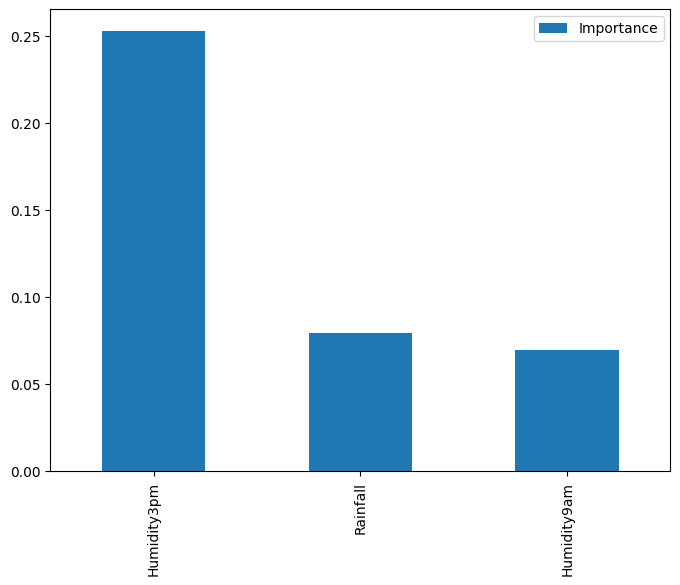

In [165]:
feat_importances = pd.DataFrame(grid_forest.best_estimator_.feature_importances_, index=X_train.columns, columns=["Importance"])
feat_importances.sort_values(by='Importance', ascending=False, inplace=True)
#print(feat_importances.head(3))
feat_importances.head(3).plot(kind='bar', figsize=(8,6))